<a href="https://colab.research.google.com/github/tjdux/Introduction-to-Machine-Learning-with-Python/blob/main/05_3_%ED%8F%89%EA%B0%80_%EC%A7%80%ED%91%9C%EC%99%80_%EC%B8%A1%EC%A0%95.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 노트북이 코랩에서 실행 중인지 체크합니다.
import os
import sys
if 'google.colab' in sys.modules and not os.path.isdir('mglearn'):
    # mglearn을 다운받고 압축을 풉니다.
    !wget -q -O mglearn.tar.gz https://bit.ly/mglearn-tar-gz
    !tar -xzf mglearn.tar.gz
    !wget -q -O data.tar.gz https://bit.ly/data-tar-gz
    !tar -xzf data.tar.gz
    # 나눔 폰트를 설치합니다.
    !sudo apt-get -qq -y install fonts-nanum
    import matplotlib.font_manager as fm
    font_files = fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum'])
    for fpath in font_files:
        fm.fontManager.addfont(fpath)

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 117528 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [2]:
import sklearn
from preamble import *
import matplotlib

# 나눔 폰트를 사용합니다.
matplotlib.rc('font', family='NanumBarunGothic')
matplotlib.rcParams['axes.unicode_minus'] = False

/content/mglearn/datasets.py:31: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


## 01 최종 목표를 기억하라
- 머신러닝 평가 지표를 선택하기 전 애플리케이션의 고차원적인 목표인 비즈니스 지표를 생각해야 함
- **비즈니스 임팩트**: 어떤 머신러닝 애플리케이션에서 특정 알고리즘을 선택하여 나타난 결과
- 비즈니스 지표에 긍정적인 영향을 주는 모델과 매개변수를 선택해야 함

## 02 이진 분류의 평가 지표
- 이진 분류에는 양성 클래스와 음성 클래스가 있으며 양성 클래스가 우리의 관심 클래스

### 2.1 에러의 종류
- **거짓 양성 (false positive)**: 잘못된 양성 예측 (타입 Ⅰ 에러)
- **거짓 음성 (false negative)**: 잘못된 음성 예측 (타입 Ⅱ 에러)
- 분류 오류가 실제 현실에서 어떤 결과를 초래하는지 살펴보아야 함: 거짓 양성과 거짓 음성 사이의 중요도를 비교해야 함

### 2.2 불균형 데이터셋
- 거짓 양성과 거짓 음성은 두 클래스 중 하나가 다른 것보다 훨씬 많을 때 더 중요
- **불균형 데이터셋**(imbalanced datasets): 한 클래스가 다른 것보다 훨씬 많은 데이터셋
- 노출 데이터로 클릭을 예측하는 경우...
  - 샘플의 99%가 '클릭 아님' 클래스에 속하는 불균형 데이터셋
  - 무조건 '클릭 아님'으로 예측하면 그 정확도는 99% 👉 정확도로는 '무조건 클릭 아님' 모델과 '진짜 좋은 모델'을 구분하기 어려움


In [4]:
# 9:1의 불균형한 데이터셋 생성
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

digits = load_digits()
y = digits.target == 9

X_train, X_test, y_train, y_test = train_test_split(
    digits.data, y, random_state=0
)

In [5]:
# DummyClassifier: 항상 다수인 클래스 (9 아님)를 예측값으로 내놓음
from sklearn.dummy import DummyClassifier

dummy_majority = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
pred_most_frequent = dummy_majority.predict(X_test)

print(f"예측된 레이블의 레이블: {np.unique(pred_most_frequent)}")
print(f"테스트 점수: {round(dummy_majority.score(X_test, y_test), 2)}")

예측된 레이블의 레이블: [False]
테스트 점수: 0.9


In [6]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(max_depth=2).fit(X_train, y_train)
pred_tree = tree.predict(X_test)

print(f"테스트 점수: {round(tree.score(X_test, y_test), 2)}")

테스트 점수: 0.92


In [12]:
from sklearn.linear_model import LogisticRegression

# strategy="stratified": 클래스 레이블의 비율과 같은 비율로 예측 결과 생성
dummy_majority = DummyClassifier(strategy="stratified").fit(X_train, y_train)
pred_dummy = dummy_majority.predict(X_test)
print(f"dummy 점수: {round(dummy_majority.score(X_test, y_test), 2)}")

logreg = LogisticRegression(C=0.1, max_iter=1000).fit(X_train, y_train)
pred_logreg = logreg.predict(X_test)
print(f"logreg 점수: {round(logreg.score(X_test, y_test), 2)}")

dummy 점수: 0.82
logreg 점수: 0.98


### 2.3 오차 행렬 (confusion matrix)
- 이진 분류 평가 결과를 나타낼 때 가장 널리 사용하는 방법

In [8]:
from sklearn.metrics import confusion_matrix

confusion = confusion_matrix(y_test, pred_logreg)
print(f"오차 행렬:\n{confusion}")

오차 행렬:
[[402   1]
 [  6  41]]


- 행: 정답 클래스
- 열: 예측 클래스

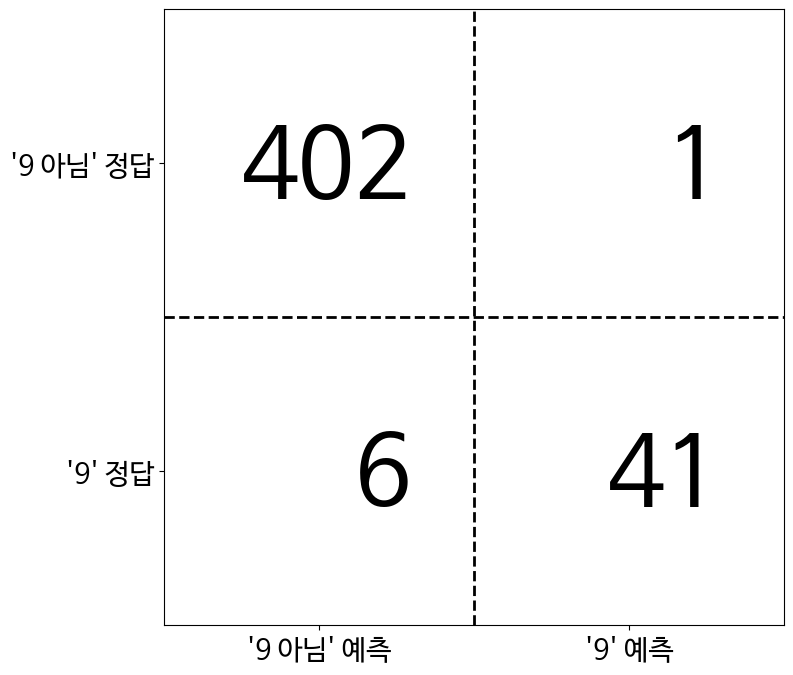

In [9]:
# '9와 9 아님' 분류 문제의 오차 행렬
mglearn.plots.plot_confusion_matrix_illustration()

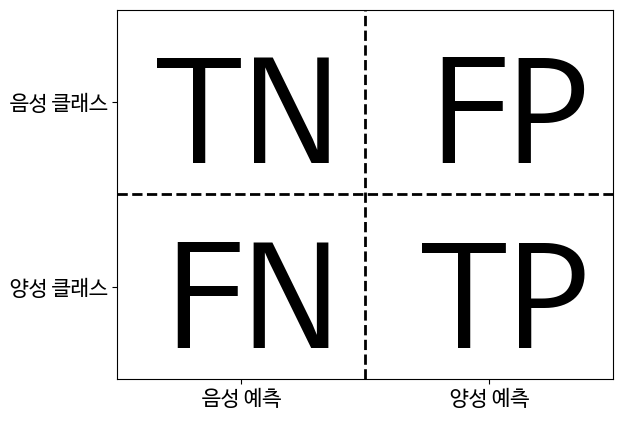

In [10]:
# 이진 분류의 오차 행렬
mglearn.plots.plot_binary_confusion_matrix()

In [13]:
# 앞서 만든 모델들의 오차 행렬 비교
print(f"빈도 기반 더미 모델:\n{confusion_matrix(y_test, pred_most_frequent)}")
print(f"\n무작위 더미 모델:\n{confusion_matrix(y_test, pred_dummy)}")
print(f"\n결정 트리:\n{confusion_matrix(y_test, pred_tree)}")
print(f"\n로지스틱 회귀:\n{confusion_matrix(y_test, pred_logreg)}")

빈도 기반 더미 모델:
[[356  47]
 [ 46   1]]

무작위 더미 모델:
[[369  34]
 [ 42   5]]

결정 트리:
[[390  13]
 [ 24  23]]

로지스틱 회귀:
[[402   1]
 [  6  41]]


- 👉 결정 트리와 로지스틱 회귀의 결과만 정상이며 로지스틱 회귀가 모든 항목에서 트리 모델보다 잘 작동했음

#### 오차 행렬 정보 요약

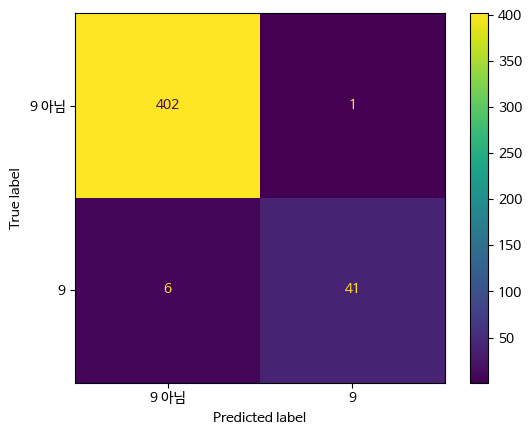

In [14]:
# ConfusionMatirxDisplay.from_estimator(): 추정기 객체로부터 오차 행렬을 그림
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(logreg, X_test, y_test,
                                      display_labels=["9 아님", "9"])
plt.show()

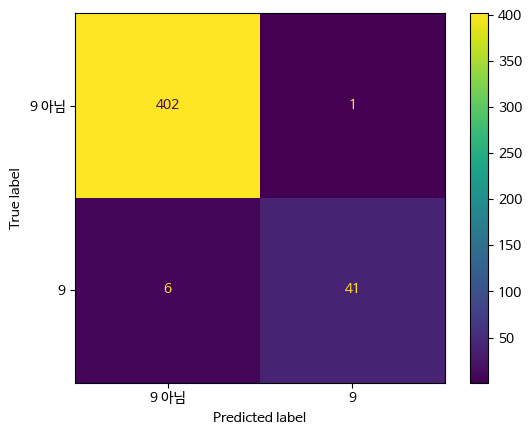

In [15]:
# ConfusionMatirxDisplay.from_predictions(): 예측 결과로부터 오차 행렬을 그림

ConfusionMatrixDisplay.from_predictions(y_test, pred_logreg,
                                        display_labels=["9 아님", "9"])
plt.show()

#### 정확도와의 관계
$$정확도 = \frac{TP + TN}{TP + TN + FP+ FN}$$
- 정확도 = 정확히 예측한 수 ($TP$, $TN$)를 전체 샘플 수로 나눈 값

#### 정밀도, 재현율, f-점수


##### 정밀도 (precision)
$$정밀도 = \frac{TP}{TP+FP}$$
- 양성으로 예측된 것 중 얼마나 많은 샘플이 진짜 양성인지 측정
- 거짓 양성 ($FP$)의 수를 줄이는 것이 목표일 때 성능 지표로 사용 (e.g. 단 한 번의 신약 임상 실험)
- 양성 예측도 (PPV)라고도 함

##### 재현율 (recall)
$$재현율 = \frac{TP}{TP+FN}$$
- 전체 양성 샘플 중에서 얼마나 많은 샘플이 양성 클래스로 분류되는지를 측정
- 모든 양성 샘플을 식별해야 할 때 성능 지표로 사용
- 거짓 음성 ($FN$)을 피하는 것이 중요할 때 사용 (e.g. 암 진단)
- 민감도 (sensitivity), 적중률(hit rate), 진짜 양성 비율(TPR)이라고도 함

##### f-점수 (f-score)
- 재현율 최적화와 정밀도 최적화는 상충
  - 모든 샘플을 진짜 음성이 하나도 없고 모두 양성 클래스에 속한다고 예측하면, 거짓 음성($FN$)이 없어져 재현율이 완벽해짐
  - 하지만 거짓 양성 ($FP$)이 많이 만들어지고 따라서 정밀도는 매우 낮아짐
- f-점수
  - 정밀도와 재현율의 조화 평균
  - 정밀도와 재현율을 하나로 요약
  $$F = 2 \times \frac{precision \times recall}{precision+recall}$$


In [16]:
from sklearn.metrics import f1_score

print(f"빈도 기반 더미 모델의 f1 score: {round(f1_score(y_test, pred_most_frequent), 2)}")
print(f"무작위 더미 모델의 f1 score: {round(f1_score(y_test, pred_dummy), 2)}")
print(f"트리 모델의 f1 score: {round(f1_score(y_test, pred_tree), 2)}")
print(f"로지스틱 회귀 모델의 f1 score: {round(f1_score(y_test, pred_logreg), 2)}")

빈도 기반 더미 모델의 f1 score: 0.02
무작위 더미 모델의 f1 score: 0.12
트리 모델의 f1 score: 0.55
로지스틱 회귀 모델의 f1 score: 0.92


- 장점: 어떤 모델이 좋은지 직관적으로 판단하는 데는 정확도보다 나음
- 단점: 정확도보다 이해하거나 설명하기 어려움

##### `classification_report()`
- 정밀도, 재현율, f-score 모두를 한 번에 계산

In [17]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred_most_frequent,
                            target_names=["9 아님", "9"], zero_division=0))

              precision    recall  f1-score   support

        9 아님       0.89      0.88      0.88       403
           9       0.02      0.02      0.02        47

    accuracy                           0.79       450
   macro avg       0.45      0.45      0.45       450
weighted avg       0.80      0.79      0.79       450



- 각 클래스가 양성일 때 정밀도, 재현율, f-score를 리포트
  - 양성 클래스가 `9 아님`이라면 f-1 점수는 0.94
- support (지지도): 해당 클래스에 있는 진짜 샘플의 수
- `macro avg`: 클래스별 점수의 평균
- `weighted avg`: 클래스의 샘플 수로 가중 평균
- 👉 두 클래스를 평균한 것이므로 양성 클래스의 개념이 필요하지 않음
- 👉 양성 클래스의 정밀도나 재현율 점수만 보는 것에 비해 두 클래스를 평균하면 숫자 하나로 된 의미 있는 지표를 얻을 수 있음

In [18]:
# 무작위 더미 분류기의 리포트
print(classification_report(y_test, pred_dummy,
                            target_names=["9 아님", "9"]))

              precision    recall  f1-score   support

        9 아님       0.90      0.92      0.91       403
           9       0.13      0.11      0.12        47

    accuracy                           0.83       450
   macro avg       0.51      0.51      0.51       450
weighted avg       0.82      0.83      0.82       450



In [20]:
# 로지스틱 분류의 리포트
print(classification_report(y_test, pred_logreg,
                            target_names=["9 아님", "9"]))

              precision    recall  f1-score   support

        9 아님       0.99      1.00      0.99       403
           9       0.98      0.87      0.92        47

    accuracy                           0.98       450
   macro avg       0.98      0.93      0.96       450
weighted avg       0.98      0.98      0.98       450



- 👉 어떤 클래스를 양성 클래스로 선택하느냐가 평가 지표에 큰 영향을 끼침